# 📊 K-Nearest Neighbors (KNN) para Regresión

## 1️⃣ ¿Qué es KNN Regressor?

**K-Nearest Neighbors (KNN) Regressor** es un algoritmo de **aprendizaje supervisado** y **no paramétrico**.

📌 A diferencia de modelos como regresión lineal o SVR:
- KNN **no aprende una función**
- Guarda los datos de entrenamiento
- Predice usando los **k vecinos más cercanos**

---

## 2️⃣ Idea matemática (conceptual)

Dado un punto nuevo \( x \):

1. Se calcula la distancia a todos los puntos del dataset
2. Se seleccionan los **k más cercanos**
3. La predicción es el **promedio** de sus valores:

$$
\hat{y}(x) = \frac{1}{k} \sum_{i \in N_k(x)} y_i
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
# Relación simple: y = 3x + ruido
X = np.arange(1, 21).reshape(-1, 1)
y = 3 * X.ravel() + np.random.randn(20)

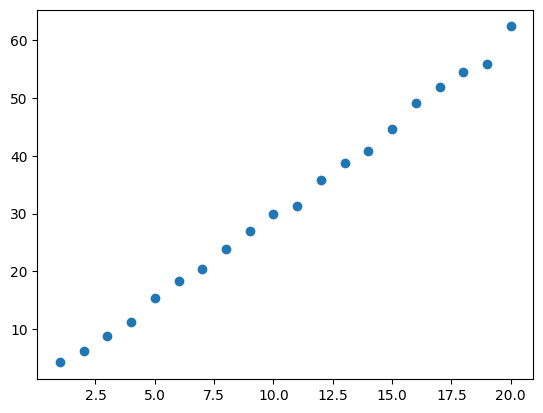

In [3]:
plt.scatter(X, y)
plt.show()

In [4]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# CREAMOS UN MODELO KNN REGRESSOR

In [5]:
knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance")
knn.fit(X_scaled, y_scaled)

KNeighborsRegressor(weights='distance')

In [6]:
X_future = np.array([[21], [22], [23]])
X_future_scaled = scaler_X.transform(X_future)

y_future_scaled = knn.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(
    y_future_scaled.reshape(-1, 1)
)

for x, y_pred in zip(X_future.ravel(), y_future.ravel()):
    print(f"x = {x} → y ≈ {y_pred:.2f}")

x = 21 → y ≈ 57.49
x = 22 → y ≈ 56.55
x = 23 → y ≈ 56.11


# PARAMETROS

| Parámetro     | Controla               | Regla práctica        |
| ------------- | ---------------------- | --------------------- |
| `n_neighbors` | Suavidad del modelo    | Empieza con 5–7       |
| `weights`     | Importancia de vecinos | Usa `distance`        |
| `p`           | Tipo de distancia      | `2` (euclidiana)      |
| `metric`      | Medida de similitud    | Default es suficiente |
| `algorithm`   | Velocidad              | `auto`                |
| `n_jobs`      | Paralelismo            | `-1`                  |
